In [ ]:
!pip install mne pyedflib numpy pandas scikit-learn imbalanced-learn matplotlib

In [ ]:
!pip install mne pyedflib numpy pandas scipy scikit-learn tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
!wget -r -N -c -np https://physionet.org/files/chbmit/1.0.0/chb01/

--2026-04-06 08:32:36--  https://physionet.org/files/chbmit/1.0.0/chb01/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/chbmit/1.0.0/chb01/index.html’

physionet.org/files     [ <=>                ]   6.00K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-04-06 08:32:36 (221 MB/s) - ‘physionet.org/files/chbmit/1.0.0/chb01/index.html’ saved [6149]

Loading robots.txt; please ignore errors.
--2026-04-06 08:32:36--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-04-06 08:32:36--  https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awai

In [22]:
import mne
import os
import numpy as np
data_path = "/content/physionet.org/files/chbmit/1.0.0/chb01"

files = [f for f in os.listdir(data_path) if f.endswith(".edf")]
files.sort()

print(files[:5])

['chb01_01.edf', 'chb01_02.edf', 'chb01_03.edf', 'chb01_04.edf', 'chb01_05.edf']


In [23]:
#can be deleted
summary_file = os.path.join(data_path, "chb01-summary.txt")

with open(summary_file, "r") as f:
    summary = f.read()

print(summary[:1000])

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

In [24]:
seizure_info = {}

current_file = None

with open(summary_file, "r") as f:
    for line in f:
        line = line.strip()

        if "File Name" in line:
            current_file = line.split(": ")[1]
            seizure_info[current_file] = []

        elif "Seizure" in line and "Start Time" in line:
            start = int(line.split(": ")[1].split()[0])

        elif "Seizure" in line and "End Time" in line:
            end = int(line.split(": ")[1].split()[0])
            seizure_info[current_file].append((start, end))

print(seizure_info)

{'chb01_01.edf': [], 'chb01_02.edf': [], 'chb01_03.edf': [(2996, 3036)], 'chb01_04.edf': [(1467, 1494)], 'chb01_05.edf': [], 'chb01_06.edf': [], 'chb01_07.edf': [], 'chb01_08.edf': [], 'chb01_09.edf': [], 'chb01_10.edf': [], 'chb01_11.edf': [], 'chb01_12.edf': [], 'chb01_13.edf': [], 'chb01_14.edf': [], 'chb01_15.edf': [(1732, 1772)], 'chb01_16.edf': [(1015, 1066)], 'chb01_17.edf': [], 'chb01_18.edf': [(1720, 1810)], 'chb01_19.edf': [], 'chb01_20.edf': [], 'chb01_21.edf': [(327, 420)], 'chb01_22.edf': [], 'chb01_23.edf': [], 'chb01_24.edf': [], 'chb01_25.edf': [], 'chb01_26.edf': [(1862, 1963)], 'chb01_27.edf': [], 'chb01_29.edf': [], 'chb01_30.edf': [], 'chb01_31.edf': [], 'chb01_32.edf': [], 'chb01_33.edf': [], 'chb01_34.edf': [], 'chb01_36.edf': [], 'chb01_37.edf': [], 'chb01_38.edf': [], 'chb01_39.edf': [], 'chb01_40.edf': [], 'chb01_41.edf': [], 'chb01_42.edf': [], 'chb01_43.edf': [], 'chb01_46.edf': []}


In [25]:
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 50)
}

In [26]:
from scipy.signal import welch

def bandpower(signal, sfreq, band):
    low, high = band
    freqs, psd = welch(signal, sfreq)

    idx = (freqs >= low) & (freqs <= high)

    return np.sum(psd[idx])

In [27]:
def shannon_entropy(signal):
    hist, _ = np.histogram(signal, bins=50, density=True)
    hist = hist + 1e-6  # avoid log(0)
    return -np.sum(hist * np.log(hist))

In [28]:
#full feature extraction
from scipy.stats import skew, kurtosis

def extract_features(segment, sfreq):
    features = []

    for ch in segment:

        # -------- TIME DOMAIN --------
        features.append(np.mean(ch))
        features.append(np.std(ch))
        features.append(np.max(ch))
        features.append(np.min(ch))
        features.append(skew(ch))
        features.append(kurtosis(ch))

        # -------- NONLINEAR --------
        features.append(shannon_entropy(ch))

        # -------- FREQUENCY --------
        for band in bands.values():
            features.append(bandpower(ch, sfreq, band))

    return features

In [29]:
def segment_signal(raw, window_sec=5):
    data = raw.get_data()
    sfreq = raw.info['sfreq']

    window_size = int(window_sec * sfreq)

    segments = []

    for start in range(0, data.shape[1] - window_size, window_size):
        seg = data[:, start:start+window_size]
        segments.append(seg)

    return np.array(segments), sfreq

In [30]:
def label_segments(file_name, num_segments, sfreq, window_sec=5):

    seizure_times = seizure_info.get(file_name, [])

    labels = []

    for i in range(num_segments):
        seg_start = i * window_sec
        seg_end = seg_start + window_sec

        label = 0

        for (start, end) in seizure_times:
            overlap = max(0, min(seg_end, end) - max(seg_start, start))

            if overlap >= 3:
                label = 1
                break

        labels.append(label)

    return labels

In [31]:
X = []
y = []

for file in files:

    raw = mne.io.read_raw_edf(os.path.join(data_path, file), preload=True)

    segments, sfreq = segment_signal(raw)
    labels = label_segments(file, len(segments), sfreq)
    print("Function exists:", segment_signal)
    for seg, label in zip(segments, labels):
        feat = extract_features(seg, sfreq)

        X.append(feat)
        y.append(label)

X = np.array(X)
y = np.array(y)

Extracting EDF parameters from /content/physionet.org/files/chbmit/1.0.0/chb01/chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_7642/1907967461.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path, file), preload=True)


Function exists: <function segment_signal at 0x7edab77654e0>
Extracting EDF parameters from /content/physionet.org/files/chbmit/1.0.0/chb01/chb01_02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_7642/1907967461.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path, file), preload=True)


Function exists: <function segment_signal at 0x7edab77654e0>
Extracting EDF parameters from /content/physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


...

Extracting EDF parameters from /content/physionet.org/files/chbmit/1.0.0/chb01/chb01_43.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_7642/1907967461.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path, file), preload=True)


Function exists: <function segment_signal at 0x7edab77654e0>
Extracting EDF parameters from /content/physionet.org/files/chbmit/1.0.0/chb01/chb01_46.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_7642/1907967461.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path, file), preload=True)


Function exists: <function segment_signal at 0x7edab77654e0>


In [39]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Total samples:", len(X))
print("Seizure samples:", np.sum(y))
print("Non-seizure samples:", len(y) - np.sum(y))

X shape: (29156, 276)
y shape: (29156,)
Total samples: 29156
Seizure samples: 90
Non-seizure samples: 29066


In [40]:
#handling imbalance since 1:322 ratio
from sklearn.utils import resample

X_seizure = X[y==1]
X_non = X[y==0]

X_non_down = resample(X_non, replace=False, n_samples=len(X_seizure), random_state=42)

X_bal = np.vstack((X_seizure, X_non_down))
y_bal = np.array([1]*len(X_seizure) + [0]*len(X_seizure))

In [41]:
from sklearn.utils import shuffle

X_bal, y_bal = shuffle(X_bal, y_bal, random_state=42)

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_bal_scaled = scaler.fit_transform(X_bal)

In [43]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_bal_scaled, y_bal)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [44]:
import joblib

joblib.dump(scaler, "/content/drive/MyDrive/chb01_scaler.pkl")
joblib.dump(model, "/content/drive/MyDrive/chb01_rf_model.pkl")

print("Saved!")

Saved!


In [45]:
!wget -r -N -c -np https://physionet.org/files/chbmit/1.0.0/chb02/

--2026-04-06 13:31:45--  https://physionet.org/files/chbmit/1.0.0/chb02/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/chbmit/1.0.0/chb02/index.html’

physionet.org/files     [ <=>                ]   4.83K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-04-06 13:31:45 (1.01 GB/s) - ‘physionet.org/files/chbmit/1.0.0/chb02/index.html’ saved [4949]

Loading robots.txt; please ignore errors.
--2026-04-06 13:31:45--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-04-06 13:31:45--  https://physionet.org/files/chbmit/1.0.0/chb02/chb02-summary.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awa

In [49]:
import shutil
shutil.copytree(
    "/content/physionet.org/files/chbmit/1.0.0/chb02",
    "/content/drive/MyDrive/chb02",
    dirs_exist_ok=True
)
print("CHB02 saved to Drive!")

FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/chb02'

In [50]:
# Load CHB02 files
import os
import mne
import numpy as np

data_path_chb02 = "/content/physionet.org/files/chbmit/1.0.0/chb02"
summary_file_chb02 = os.path.join(data_path_chb02, "chb02-summary.txt")

files_chb02 = sorted([f for f in os.listdir(data_path_chb02) if f.endswith(".edf")])
print(files_chb02[:5])

['chb02_01.edf', 'chb02_02.edf', 'chb02_03.edf', 'chb02_04.edf', 'chb02_05.edf']


In [51]:
#Parse CHB02 seizure timestamps
seizure_info_chb02 = {}
current_file = None

with open(summary_file_chb02, "r") as f:
    for line in f:
        line = line.strip()
        if "File Name" in line:
            current_file = line.split(": ")[1]
            seizure_info_chb02[current_file] = []
        elif "Seizure" in line and "Start Time" in line:
            start = int(line.split(": ")[1].split()[0])
        elif "Seizure" in line and "End Time" in line:
            end = int(line.split(": ")[1].split()[0])
            seizure_info_chb02[current_file].append((start, end))

print(seizure_info_chb02)

{'chb02_01.edf': [], 'chb02_02.edf': [], 'chb02_03.edf': [], 'chb02_04.edf': [], 'chb02_05.edf': [], 'chb02_06.edf': [], 'chb02_07.edf': [], 'chb02_08.edf': [], 'chb02_09.edf': [], 'chb02_10.edf': [], 'chb02_11.edf': [], 'chb02_12.edf': [], 'chb02_13.edf': [], 'chb02_14.edf': [], 'chb02_15.edf': [], 'chb02_16.edf': [(130, 212)], 'chb02_16+.edf': [(2972, 3053)], 'chb02_17.edf': [], 'chb02_18.edf': [], 'chb02_19.edf': [(3369, 3378)], 'chb02_20.edf': [], 'chb02_21.edf': [], 'chb02_22.edf': [], 'chb02_23.edf': [], 'chb02_24.edf': [], 'chb02_25.edf': [], 'chb02_26.edf': [], 'chb02_27.edf': [], 'chb02_28.edf': [], 'chb02_29.edf': [], 'chb02_30.edf': [], 'chb02_31.edf': [], 'chb02_32.edf': [], 'chb02_33.edf': [], 'chb02_34.edf': [], 'chb02_35.edf': []}


In [52]:
# Extract CHB02 features
X_test, y_test = [], []

for file in files_chb02:
    raw = mne.io.read_raw_edf(os.path.join(data_path_chb02, file), preload=True, verbose=False)
    segments, sfreq = segment_signal(raw)

    for i, seg in enumerate(segments):
        seg_start = i * 5
        seg_end = seg_start + 5
        label = 0
        for (start, end) in seizure_info_chb02.get(file, []):
            if max(0, min(seg_end, end) - max(seg_start, start)) >= 3:
                label = 1
                break
        X_test.append(extract_features(seg, sfreq))
        y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)
print("X_test shape:", X_test.shape)
print("Seizure windows:", np.sum(y_test), "| Non-seizure:", len(y_test) - np.sum(y_test))

/tmp/ipykernel_7642/1778258920.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path_chb02, file), preload=True, verbose=False)
/tmp/ipykernel_7642/1778258920.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path_chb02, file), preload=True, verbose=False)
/tmp/ipykernel_7642/1778258920.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path_chb02, file), preload=True, verbose=False)
/tmp/ipykernel_7642/1778258920.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(data_path_chb02, file), preload=True, verbose=Fal

X_test shape: (25356, 276)
Seizure windows: 35 | Non-seizure: 25321


In [53]:
# Channel mismatch check
sample_chb01 = mne.io.read_raw_edf(
    os.path.join(data_path, files[0]), preload=False, verbose=False
)
sample_chb02 = mne.io.read_raw_edf(
    os.path.join(data_path_chb02, files_chb02[0]), preload=False, verbose=False
)

print("CHB01 channels:", len(sample_chb01.ch_names))
print("CHB02 channels:", len(sample_chb02.ch_names))
print("Match?", sample_chb01.ch_names == sample_chb02.ch_names)

CHB01 channels: 23
CHB02 channels: 23
Match? True


/tmp/ipykernel_7642/2757267644.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  sample_chb01 = mne.io.read_raw_edf(
/tmp/ipykernel_7642/2757267644.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  sample_chb02 = mne.io.read_raw_edf(


              precision    recall  f1-score   support

 Non-seizure       1.00      0.94      0.97     25321
     Seizure       0.02      0.94      0.04        35

    accuracy                           0.94     25356
   macro avg       0.51      0.94      0.51     25356
weighted avg       1.00      0.94      0.97     25356



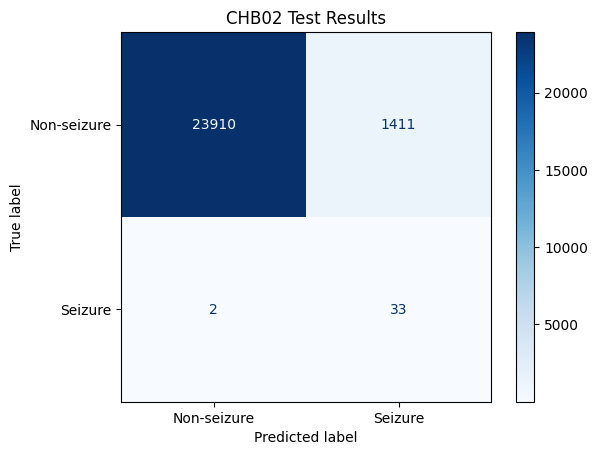

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_test_scaled = scaler.transform(X_test)  # transform only, NOT fit_transform
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=["Non-seizure", "Seizure"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Non-seizure", "Seizure"]).plot(cmap="Blues")
plt.title("CHB02 Test Results")
plt.show()